In [1]:
# ============================================
# PORTFOLIO OPTIMISATION
# Mean-Variance Optimisation (Markowitz, 1952)
# ============================================
# Takes the top candidate stocks from both models
# and finds the mathematically optimal portfolio
# weights that maximise the Sharpe ratio.
#
# Inputs:  data/ml/feature_columns.csv
#          data/ml/rf_model.joblib
#          data/master_features_latest.csv
#          data/prices/ (daily OHLCV)
#
# Outputs: data/portfolio_optimisation/
#          - efficient_frontier.png
#          - optimal_weights.csv
#          - portfolio_comparison.csv
#          - portfolio_summary.png
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import joblib
import os
import warnings
from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('data/portfolio_optimisation', exist_ok=True)

print("=" * 60)
print("PORTFOLIO OPTIMISATION")
print("Mean-Variance Optimisation (Markowitz, 1952)")
print("=" * 60)
print("\n✓ Libraries loaded")

PORTFOLIO OPTIMISATION
Mean-Variance Optimisation (Markowitz, 1952)

✓ Libraries loaded


In [2]:
# ============================================
# STEP 1: LOAD DATA AND MODELS
# ============================================

print("\n[Step 1] Loading data and models...")

# Load trained RF model
rf_model = joblib.load('data/ml/rf_model.joblib')
print("✓ Random Forest model loaded")

# Load feature columns
feature_cols = pd.read_csv(
    'data/ml/feature_columns.csv')['Feature'].tolist()
print(f"✓ Feature columns loaded ({len(feature_cols)} features)")

# Load latest master features (for scoring)
master_df = pd.read_csv('data/master_features_latest.csv')
print(f"✓ Master features loaded ({len(master_df)} stocks)")

# Load stock universe (for company names)
universe = pd.read_csv('data/stock_universe_clean.csv')
if 'Company_Name' not in master_df.columns:
    master_df = master_df.merge(
        universe[['Ticker', 'Company_Name']], on='Ticker', how='left')

# Load all daily price data
print("\nLoading daily price data...")
price_data = {}
price_dir = 'data/prices/'
for fname in os.listdir(price_dir):
    if not fname.endswith('.csv'):
        continue
    ticker = fname.replace('.csv', '') + '.SI'
    try:
        df = pd.read_csv(
            os.path.join(price_dir, fname),
            index_col=0, parse_dates=True)
        # Remove timezone
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        price_data[ticker] = df
    except Exception:
        pass

print(f"✓ Price data loaded for {len(price_data)} stocks")
print("\n✓ All data loaded successfully")


[Step 1] Loading data and models...
✓ Random Forest model loaded
✓ Feature columns loaded (29 features)
✓ Master features loaded (55 stocks)

Loading daily price data...
✓ Price data loaded for 55 stocks

✓ All data loaded successfully


In [3]:
# ============================================
# STEP 2: SCORE ALL STOCKS AND SELECT
#         TOP CANDIDATES FOR OPTIMISATION
# ============================================

print("\n[Step 2] Scoring stocks and selecting candidates...")

# ---- Factor scoring function ----
def compute_factor_score(row):
    """
    Production factor model — identical to FYP_Development.ipynb.
    Weights: 40% growth, 40% quality, 20% risk.
    """
    score = 0
    # Growth (40%)
    if pd.notna(row.get('Revenue_Growth')):
        rev = np.clip(row['Revenue_Growth'], -0.5, 1.0)
        score += ((rev + 0.5) / 1.5 * 100) * 0.20
    if pd.notna(row.get('EPS')):
        eps = np.clip(row['EPS'], -1, 5)
        score += ((eps + 1) / 6 * 100) * 0.10
    if pd.notna(row.get('Return_6M')):
        mom = np.clip(row['Return_6M'], -0.5, 1.0)
        score += ((mom + 0.5) / 1.5 * 100) * 0.10
    # Quality (40%)
    if pd.notna(row.get('ROE')):
        roe = np.clip(row['ROE'], -0.2, 0.4)
        score += ((roe + 0.2) / 0.6 * 100) * 0.15
    if pd.notna(row.get('Profit_Margin')):
        margin = np.clip(row['Profit_Margin'], -0.2, 0.5)
        score += ((margin + 0.2) / 0.7 * 100) * 0.10
    if pd.notna(row.get('Debt_to_Equity')):
        debt = np.clip(row['Debt_to_Equity'], 0, 300)
        score += ((300 - debt) / 300 * 100) * 0.10
    if pd.notna(row.get('Market_Cap')):
        mcap_log = np.log10(max(row['Market_Cap'], 1e6))
        score += np.clip((mcap_log - 6) / 5.2 * 100, 0, 100) * 0.05
    # Risk (20%)
    if pd.notna(row.get('Volatility')) and row['Volatility'] > 0:
        vol = np.clip(row['Volatility'], 0.1, 0.8)
        score += ((0.8 - vol) / 0.7 * 100) * 0.10
    if pd.notna(row.get('Max_Drawdown')):
        dd = np.clip(row['Max_Drawdown'], -0.6, 0)
        score += ((dd + 0.6) / 0.6 * 100) * 0.10
    return score

# ---- Prepare ML features with sector encoding ----
def prepare_ml_features(df, feature_cols):
    df = df.copy()
    if 'Sector' in df.columns:
        dummies = pd.get_dummies(df['Sector'], prefix='Sector')
        df = pd.concat([df, dummies], axis=1)
    for col in feature_cols:
        if col.startswith('Sector_') and col not in df.columns:
            df[col] = 0
    X = df[feature_cols].copy()
    X = X.fillna(X.median())
    return X

# ---- Score all stocks ----
df = master_df.copy()
df['Factor_Score']   = df.apply(compute_factor_score, axis=1)
X_all                = prepare_ml_features(df, feature_cols)
df['ML_Probability'] = rf_model.predict_proba(X_all)[:, 1]

# ---- Rank ----
df['Factor_Rank'] = df['Factor_Score'].rank(
    ascending=False, method='min').astype(int)
df['ML_Rank']     = df['ML_Probability'].rank(
    ascending=False, method='min').astype(int)

# ---- Select top candidates ----
TOP_N = 10
top_factor = set(df.nsmallest(TOP_N, 'Factor_Rank')['Ticker'])
top_ml     = set(df.nsmallest(TOP_N, 'ML_Rank')['Ticker'])

# Union of both model top-10 as the candidate pool
candidate_tickers = list(top_factor | top_ml)

# Assign confidence labels
def assign_confidence(ticker):
    in_f5 = ticker in set(df.nsmallest(5, 'Factor_Rank')['Ticker'])
    in_m5 = ticker in set(df.nsmallest(5, 'ML_Rank')['Ticker'])
    in_f10 = ticker in top_factor
    in_m10 = ticker in top_ml
    if in_f5 and in_m5:
        return 'HIGH'
    elif in_f10 and in_m10:
        return 'MEDIUM'
    return 'LOW'

candidate_df = df[df['Ticker'].isin(candidate_tickers)].copy()
candidate_df['Confidence'] = candidate_df['Ticker'].apply(assign_confidence)

# Normalised combined score for sorting
f_min, f_max = df['Factor_Score'].min(), df['Factor_Score'].max()
candidate_df['Factor_Norm'] = (
    (candidate_df['Factor_Score'] - f_min) / (f_max - f_min + 1e-9))
candidate_df['Combined_Score'] = (
    candidate_df['Factor_Norm'] + candidate_df['ML_Probability']) / 2

candidate_df = candidate_df.sort_values('Combined_Score', ascending=False)

print(f"✓ Factor Model Top 10: {sorted(top_factor)}")
print(f"✓ ML Model Top 10:     {sorted(top_ml)}")
print(f"✓ Combined candidate pool: {len(candidate_tickers)} stocks")
print(f"\nCandidate stocks:")
display_cols = ['Ticker', 'Company_Name', 'Sector', 'Confidence',
                'Factor_Score', 'ML_Probability']
available_cols = [c for c in display_cols if c in candidate_df.columns]
print(candidate_df[available_cols].to_string(index=False))


[Step 2] Scoring stocks and selecting candidates...
✓ Factor Model Top 10: ['AIY.SI', 'AJBU.SI', 'BS6.SI', 'D05.SI', 'O39.SI', 'OV8.SI', 'P8Z.SI', 'S68.SI', 'U11.SI', 'Z74.SI']
✓ ML Model Top 10:     ['1D0.SI', '9CI.SI', 'BS6.SI', 'C09.SI', 'C41.SI', 'CMOU.SI', 'D05.SI', 'QC7.SI', 'U77.SI', 'Y92.SI']
✓ Combined candidate pool: 18 stocks

Candidate stocks:
 Ticker                Company_Name                 Sector Confidence  Factor_Score  ML_Probability
 BS6.SI            YZJ Shipbldg SGD            Industrials     MEDIUM     62.669951        0.717803
 D05.SI          DBS Group Holdings     Financial Services     MEDIUM     69.984076        0.531382
 S68.SI                         SGX     Financial Services        LOW     69.931174        0.372372
 AIY.SI           iFAST Corporation             Technology        LOW     63.867702        0.465329
 Z74.SI                     Singtel Communication Services        LOW     62.448983        0.457812
 P8Z.SI          Bumitama Agri Ltd.     C

In [4]:
# ============================================
# STEP 3: BUILD DAILY RETURN MATRIX
#         FROM HISTORICAL PRICE DATA
# ============================================

print("\n[Step 3] Building daily return matrix...")

# Use 2 years of price history (2022-2023) for covariance estimation
START_DATE = '2022-01-01'
END_DATE   = '2023-12-31'

daily_returns = {}
excluded = []

for ticker in candidate_tickers:
    if ticker not in price_data:
        excluded.append(f"{ticker} (no price file)")
        continue

    df_p = price_data[ticker]
    price_col = 'Price' if 'Price' in df_p.columns else 'Close'
    if price_col not in df_p.columns:
        excluded.append(f"{ticker} (no price column)")
        continue

    # Filter date range
    mask = (df_p.index >= START_DATE) & (df_p.index <= END_DATE)
    series = df_p.loc[mask, price_col].dropna()

    if len(series) < 100:
        excluded.append(f"{ticker} (insufficient data: {len(series)} rows)")
        continue

    returns = series.pct_change().dropna()
    daily_returns[ticker] = returns

if excluded:
    print(f"\n⚠ Excluded from optimisation:")
    for e in excluded:
        print(f"  - {e}")

# Build aligned return matrix (only dates where all stocks have data)
returns_df = pd.DataFrame(daily_returns)
returns_df = returns_df.dropna()

valid_tickers = list(returns_df.columns)
print(f"\n✓ Return matrix built:")
print(f"  Stocks:      {len(valid_tickers)}")
print(f"  Trading days: {len(returns_df)}")
print(f"  Date range:  {returns_df.index[0].date()} to "
      f"{returns_df.index[-1].date()}")

# Update candidate pool to only valid tickers
candidate_df = candidate_df[candidate_df['Ticker'].isin(valid_tickers)].copy()
valid_tickers = candidate_df['Ticker'].tolist()  # preserve sort order

returns_df = returns_df[valid_tickers]

print(f"\n✓ Final optimisation universe: {len(valid_tickers)} stocks")
print(f"  {valid_tickers}")


[Step 3] Building daily return matrix...

✓ Return matrix built:
  Stocks:      18
  Trading days: 498
  Date range:  2022-01-04 to 2023-12-29

✓ Final optimisation universe: 18 stocks
  ['BS6.SI', 'D05.SI', 'S68.SI', 'AIY.SI', 'Z74.SI', 'P8Z.SI', 'O39.SI', 'U11.SI', 'OV8.SI', 'C41.SI', '1D0.SI', 'QC7.SI', 'Y92.SI', 'AJBU.SI', 'C09.SI', '9CI.SI', 'U77.SI', 'CMOU.SI']


In [5]:
# ============================================
# STEP 4: MEAN-VARIANCE OPTIMISATION
# ============================================
# Finds portfolio weights w that maximise the
# Sharpe ratio:
#   Sharpe = (μ_p - r_f) / σ_p
#
# Subject to:
#   Σ wᵢ = 1   (weights sum to 1)
#   wᵢ ≥ 0     (no short selling)
#   wᵢ ≤ 0.40  (max 40% in any single stock)
# ============================================

print("\n[Step 4] Running Mean-Variance Optimisation...")

RISK_FREE_RATE = 0.04 / 252   # Singapore 3-month T-bill ~4% annualised
TRADING_DAYS   = 252
MAX_WEIGHT     = 0.40          # Max 40% per stock (concentration limit)
MIN_WEIGHT     = 0.01          # Min 1% per stock if included

n = len(valid_tickers)

# ---- Annualised expected returns (mean of daily returns × 252) ----
mean_daily   = returns_df.mean()
annual_return = mean_daily * TRADING_DAYS

# ---- Annualised covariance matrix ----
cov_matrix = returns_df.cov() * TRADING_DAYS

print(f"\nExpected annualised returns per stock:")
for t, r in annual_return.items():
    name = candidate_df[candidate_df['Ticker'] == t]['Company_Name'].values
    name_str = name[0] if len(name) > 0 else t
    print(f"  {t:12s} ({name_str:30s}): {r:+.2%}")

print(f"\nCovariance matrix shape: {cov_matrix.shape}")

# ---- Portfolio metric functions ----
def portfolio_return(weights):
    return np.dot(weights, annual_return.values)

def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix.values, weights)))

def portfolio_sharpe(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    if vol == 0:
        return 0
    return (ret - RISK_FREE_RATE * TRADING_DAYS) / vol

def neg_sharpe(weights):
    """Objective function — minimise negative Sharpe (= maximise Sharpe)."""
    return -portfolio_sharpe(weights)

# ---- Optimisation constraints and bounds ----
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}   # weights sum to 1
]

bounds = tuple((MIN_WEIGHT, MAX_WEIGHT) for _ in range(n))

# ---- Initial guess: equal weights ----
w0 = np.array([1.0 / n] * n)

# ---- Run optimisation ----
result = minimize(
    neg_sharpe,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)

if result.success:
    optimal_weights = result.x
    # Clean up tiny weights below 0.5% — set to 0 and renormalise
    optimal_weights[optimal_weights < 0.005] = 0
    if optimal_weights.sum() > 0:
        optimal_weights = optimal_weights / optimal_weights.sum()
    print("\n✓ Optimisation converged successfully")
else:
    print(f"\n⚠ Optimisation warning: {result.message}")
    print("  Using result anyway — check constraints may be binding")
    optimal_weights = result.x
    optimal_weights = np.clip(optimal_weights, 0, 1)
    optimal_weights = optimal_weights / optimal_weights.sum()

# ---- Compute optimal portfolio metrics ----
opt_return = portfolio_return(optimal_weights)
opt_vol    = portfolio_volatility(optimal_weights)
opt_sharpe = portfolio_sharpe(optimal_weights)

# ---- Equal-weight benchmark ----
eq_weights  = np.array([1.0 / n] * n)
eq_return   = portfolio_return(eq_weights)
eq_vol      = portfolio_volatility(eq_weights)
eq_sharpe   = portfolio_sharpe(eq_weights)

# ---- Print results ----
print("\n" + "=" * 60)
print("OPTIMAL PORTFOLIO vs EQUAL-WEIGHT BENCHMARK")
print("=" * 60)

print(f"\n{'Metric':<28} {'Equal-Weight':>14} {'Optimised':>14}")
print("-" * 58)
print(f"{'Expected Annual Return':<28} {eq_return:>13.2%} {opt_return:>13.2%}")
print(f"{'Annual Volatility':<28} {eq_vol:>13.2%} {opt_vol:>13.2%}")
print(f"{'Sharpe Ratio':<28} {eq_sharpe:>13.3f} {opt_sharpe:>13.3f}")
print(f"{'Max Single Stock Weight':<28} {max(eq_weights):>13.1%} "
      f"{max(optimal_weights):>13.1%}")

print("\n\nOPTIMAL PORTFOLIO WEIGHTS:")
print("-" * 60)
print(f"{'Ticker':<12} {'Company':<30} {'Confidence':<12} {'Weight':>8}")
print("-" * 60)

weights_data = []
for i, ticker in enumerate(valid_tickers):
    w = optimal_weights[i]
    if w < 0.001:
        continue
    name = candidate_df[
        candidate_df['Ticker'] == ticker]['Company_Name'].values
    name_str = name[0] if len(name) > 0 else ticker
    conf = candidate_df[
        candidate_df['Ticker'] == ticker]['Confidence'].values
    conf_str = conf[0] if len(conf) > 0 else 'LOW'
    print(f"{ticker:<12} {str(name_str):<30} {conf_str:<12} {w:>7.1%}")
    weights_data.append({
        'Ticker': ticker,
        'Company_Name': name_str,
        'Confidence': conf_str,
        'Optimal_Weight': w,
        'Equal_Weight': eq_weights[i],
        'Expected_Annual_Return': annual_return[ticker],
        'Factor_Score': candidate_df[
            candidate_df['Ticker'] == ticker]['Factor_Score'].values[0],
        'ML_Probability': candidate_df[
            candidate_df['Ticker'] == ticker]['ML_Probability'].values[0],
    })

weights_df = pd.DataFrame(weights_data)
weights_df = weights_df.sort_values('Optimal_Weight', ascending=False)


[Step 4] Running Mean-Variance Optimisation...

Expected annualised returns per stock:
  BS6.SI       (YZJ Shipbldg SGD              ): +45.96%
  D05.SI       (DBS Group Holdings            ): +7.98%
  S68.SI       (SGX                           ): +6.82%
  AIY.SI       (iFAST Corporation             ): +7.25%
  Z74.SI       (Singtel                       ): +9.33%
  P8Z.SI       (Bumitama Agri Ltd.            ): +20.65%
  O39.SI       (OCBC Bank                     ): +13.10%
  U11.SI       (United Overseas Bank          ): +8.99%
  OV8.SI       (Sheng Siong Group Ltd         ): +8.99%
  C41.SI       (Olam Group                    ): -2.66%
  1D0.SI       (Raffles Medical Group         ): -5.19%
  QC7.SI       (Cordlife Group                ): -37.94%
  Y92.SI       (Thai Beverage                 ): +168.65%
  AJBU.SI      (Keppel Infrastructure Trust   ): -4.40%
  C09.SI       (City Developments             ): +5.03%
  9CI.SI       (CapitaLand Investment         ): +2.34%
  U77.SI  

In [6]:
# ============================================
# STEP 5: EFFICIENT FRONTIER
#         (Monte Carlo Simulation)
# ============================================
# Simulates 10,000 random portfolios to trace
# the efficient frontier — showing the full
# risk/return tradeoff space.
# ============================================

print("\n[Step 5] Simulating efficient frontier (10,000 portfolios)...")

N_SIMULATIONS = 10_000

sim_returns  = np.zeros(N_SIMULATIONS)
sim_vols     = np.zeros(N_SIMULATIONS)
sim_sharpes  = np.zeros(N_SIMULATIONS)
sim_weights  = np.zeros((N_SIMULATIONS, n))

for i in range(N_SIMULATIONS):
    # Random weights that sum to 1
    w = np.random.dirichlet(np.ones(n))
    sim_weights[i]  = w
    sim_returns[i]  = portfolio_return(w)
    sim_vols[i]     = portfolio_volatility(w)
    sharpe_val      = ((sim_returns[i] - RISK_FREE_RATE * TRADING_DAYS)
                       / sim_vols[i]) if sim_vols[i] > 0 else 0
    sim_sharpes[i]  = sharpe_val

print(f"✓ {N_SIMULATIONS:,} random portfolios simulated")
print(f"  Return range:  {sim_returns.min():.2%} to {sim_returns.max():.2%}")
print(f"  Volatility range: {sim_vols.min():.2%} to {sim_vols.max():.2%}")
print(f"  Best simulated Sharpe: {sim_sharpes.max():.3f}")
print(f"  Optimised Sharpe:      {opt_sharpe:.3f}")

# ---- Minimum Variance Portfolio ----
def portfolio_variance(weights):
    return portfolio_volatility(weights)

mvp_result = minimize(
    portfolio_variance,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000}
)

mvp_weights   = mvp_result.x / mvp_result.x.sum()
mvp_return    = portfolio_return(mvp_weights)
mvp_vol       = portfolio_volatility(mvp_weights)
mvp_sharpe    = portfolio_sharpe(mvp_weights)

print(f"\n✓ Minimum Variance Portfolio:")
print(f"  Return:     {mvp_return:.2%}")
print(f"  Volatility: {mvp_vol:.2%}")
print(f"  Sharpe:     {mvp_sharpe:.3f}")


[Step 5] Simulating efficient frontier (10,000 portfolios)...
✓ 10,000 random portfolios simulated
  Return range:  -12.70% to 88.19%
  Volatility range: 8.90% to 77.60%
  Best simulated Sharpe: 1.408
  Optimised Sharpe:      1.616

✓ Minimum Variance Portfolio:
  Return:     6.43%
  Volatility: 8.06%
  Sharpe:     0.301



[Step 6] Generating visualisations...


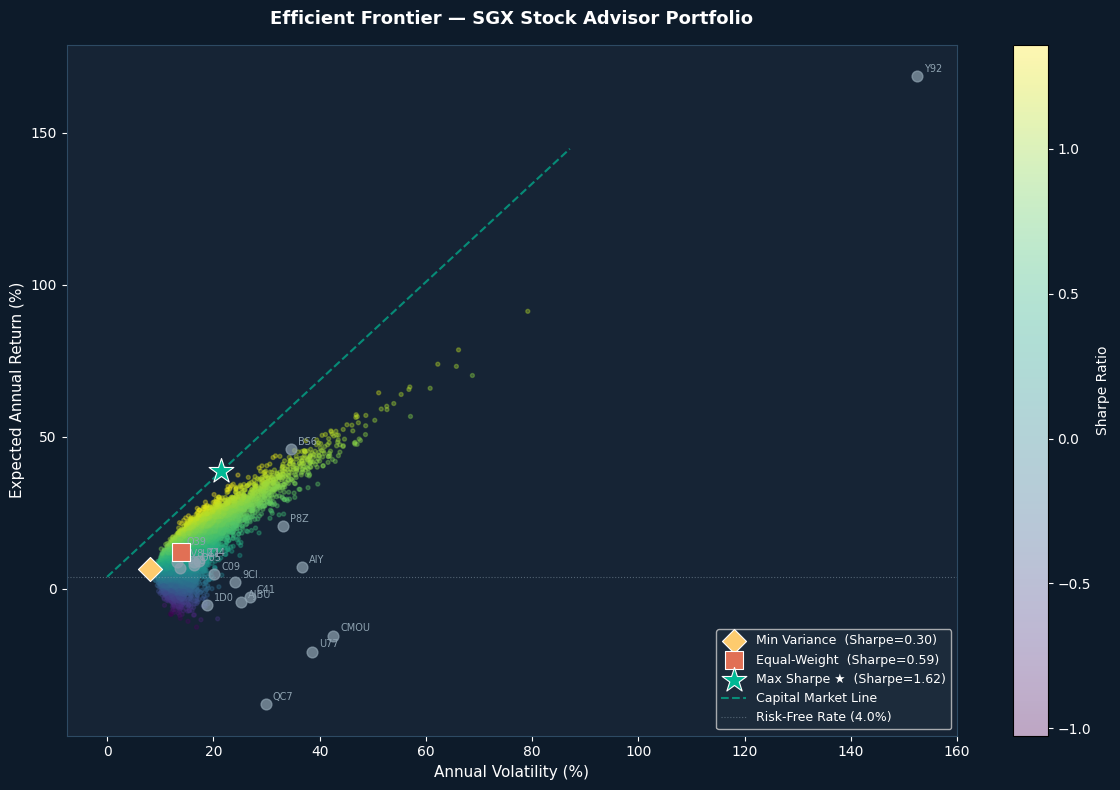

✓ Efficient frontier saved


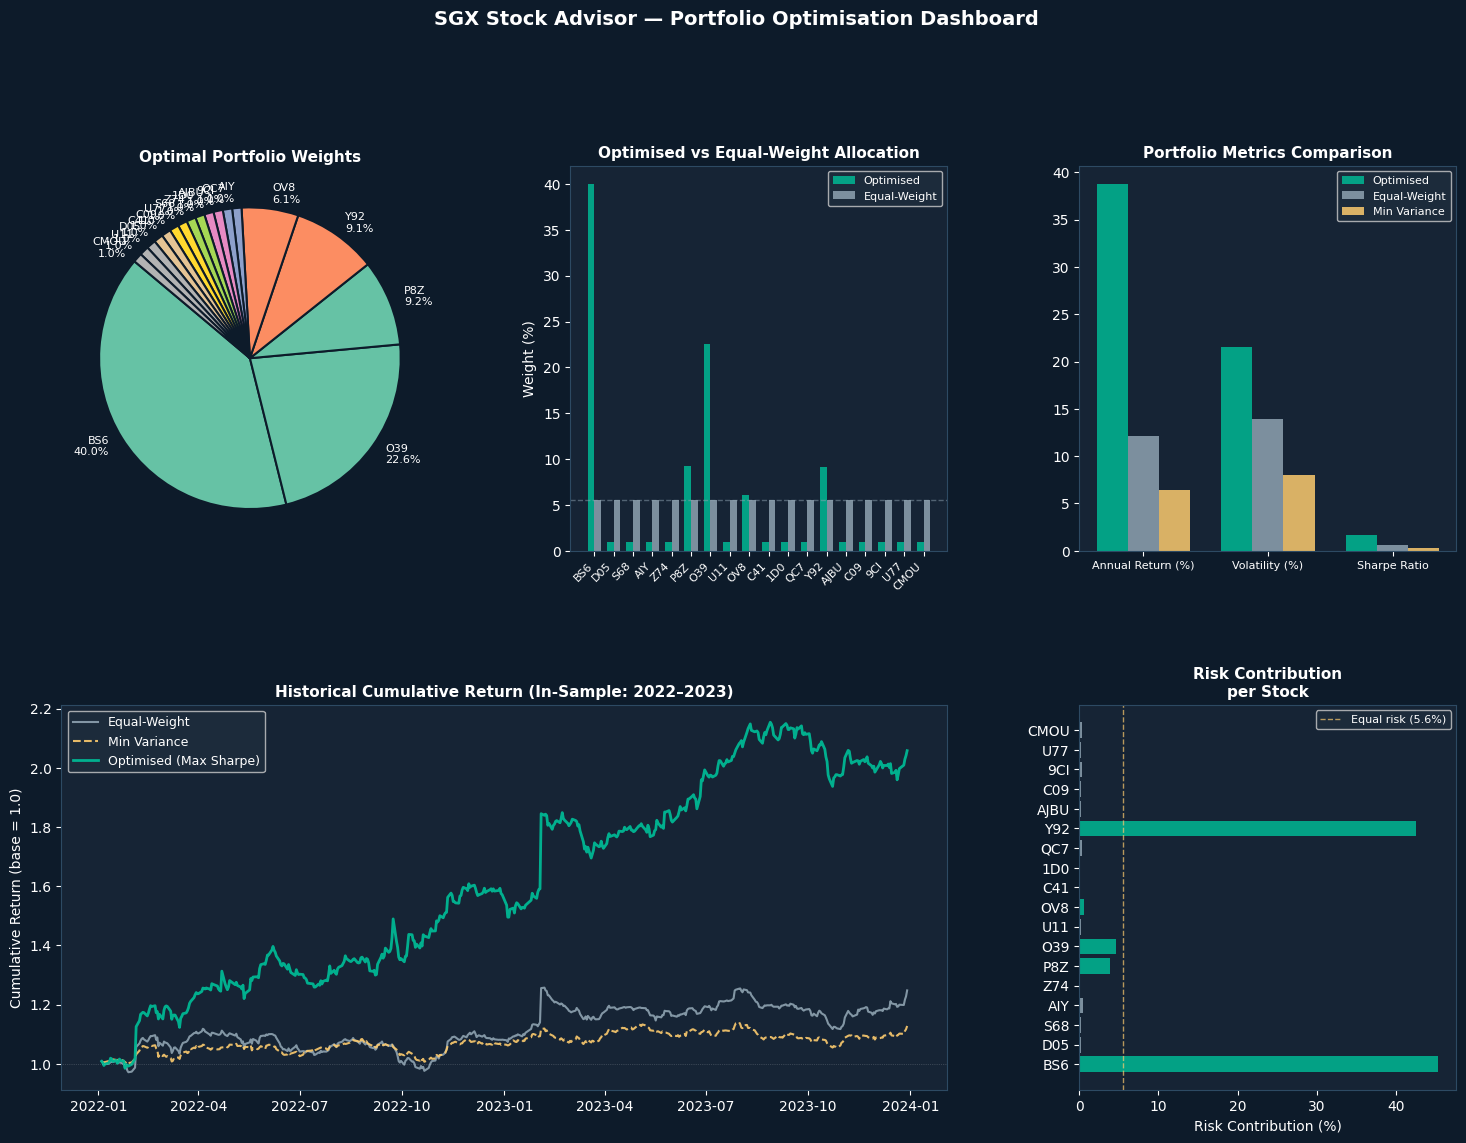

✓ Portfolio summary dashboard saved


In [8]:
# ============================================
# STEP 6: VISUALISATIONS
# ============================================

print("\n[Step 6] Generating visualisations...")

# Colour map for Sharpe ratio on scatter
DARK_BG    = '#0d1b2a'
CARD_BG    = '#162435'
GREEN      = '#00b894'
AMBER      = '#fdcb6e'
RED        = '#e17055'
PURPLE     = '#6c5ce7'
MUTED      = '#8fa3b1'

# =============================================
# FIGURE 1: EFFICIENT FRONTIER
# =============================================
fig1, ax = plt.subplots(figsize=(12, 8))
fig1.patch.set_facecolor(DARK_BG)
ax.set_facecolor(CARD_BG)

# Scatter: all simulated portfolios (coloured by Sharpe)
sc = ax.scatter(
    sim_vols * 100, sim_returns * 100,
    c=sim_sharpes, cmap='viridis',
    alpha=0.35, s=8, zorder=1
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# Individual stocks
for ticker in valid_tickers:
    s_ret = annual_return[ticker] * 100
    s_vol = np.sqrt(cov_matrix.loc[ticker, ticker]) * 100
    ax.scatter(s_vol, s_ret, s=60, color=MUTED,
               zorder=3, alpha=0.7)
    ax.annotate(
        ticker.replace('.SI', ''),
        (s_vol, s_ret),
        fontsize=7, color=MUTED,
        xytext=(5, 3), textcoords='offset points'
    )

# Minimum Variance Portfolio
ax.scatter(
    mvp_vol * 100, mvp_return * 100,
    marker='D', color=AMBER, s=150, zorder=5,
    label=f'Min Variance  (Sharpe={mvp_sharpe:.2f})',
    edgecolors='white', linewidths=0.8
)

# Equal-Weight Portfolio
ax.scatter(
    eq_vol * 100, eq_return * 100,
    marker='s', color=RED, s=150, zorder=5,
    label=f'Equal-Weight  (Sharpe={eq_sharpe:.2f})',
    edgecolors='white', linewidths=0.8
)

# Optimal (Max Sharpe) Portfolio
ax.scatter(
    opt_vol * 100, opt_return * 100,
    marker='*', color=GREEN, s=350, zorder=6,
    label=f'Max Sharpe ★  (Sharpe={opt_sharpe:.2f})',
    edgecolors='white', linewidths=0.8
)

# Capital Market Line (from risk-free rate through optimal portfolio)
rf_annual = RISK_FREE_RATE * TRADING_DAYS * 100
cml_vols  = np.linspace(0, max(sim_vols) * 100 * 1.1, 100)
if opt_vol > 0:
    cml_slope  = (opt_return * 100 - rf_annual) / (opt_vol * 100)
    cml_returns = rf_annual + cml_slope * cml_vols
    ax.plot(cml_vols, cml_returns,
            color=GREEN, linewidth=1.5, linestyle='--',
            alpha=0.7, label='Capital Market Line', zorder=4)
ax.axhline(rf_annual, color=MUTED, linewidth=0.8,
           linestyle=':', alpha=0.5,
           label=f'Risk-Free Rate ({rf_annual:.1f}%)')

ax.set_xlabel('Annual Volatility (%)', color='white', fontsize=11)
ax.set_ylabel('Expected Annual Return (%)', color='white', fontsize=11)
ax.set_title('Efficient Frontier — SGX Stock Advisor Portfolio',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.spines[:].set_color('#2d4a63')
legend = ax.legend(facecolor='#1e2d3d', labelcolor='white',
                   fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('data/portfolio_optimisation/efficient_frontier.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✓ Efficient frontier saved")

# =============================================
# FIGURE 2: PORTFOLIO SUMMARY DASHBOARD
# =============================================
fig2 = plt.figure(figsize=(18, 12))
fig2.patch.set_facecolor(DARK_BG)
gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.4, wspace=0.35)

# --- Plot 1: Optimal weights pie chart ---
ax1 = fig2.add_subplot(gs[0, 0])
ax1.set_facecolor(DARK_BG)
pie_labels  = []
pie_weights = []
for _, row in weights_df.iterrows():
    if row['Optimal_Weight'] > 0.001:
        label = row['Ticker'].replace('.SI', '')
        pie_labels.append(f"{label}\n{row['Optimal_Weight']:.1%}")
        pie_weights.append(row['Optimal_Weight'])

colours_pie = plt.cm.Set2(np.linspace(0, 1, len(pie_weights)))
wedges, texts = ax1.pie(
    pie_weights, labels=pie_labels,
    colors=colours_pie, startangle=140,
    textprops={'color': 'white', 'fontsize': 8},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 1.5}
)
ax1.set_title('Optimal Portfolio Weights', color='white',
              fontweight='bold', fontsize=11)

# --- Plot 2: Optimal vs Equal-Weight bar chart ---
ax2 = fig2.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD_BG)
tickers_short = [t.replace('.SI', '') for t in valid_tickers]
x = np.arange(len(valid_tickers))
w_bar = 0.35
bars1 = ax2.bar(x - w_bar/2, optimal_weights * 100,
                w_bar, label='Optimised', color=GREEN, alpha=0.85)
bars2 = ax2.bar(x + w_bar/2, eq_weights * 100,
                w_bar, label='Equal-Weight', color=MUTED, alpha=0.85)
ax2.axhline(100/n, color=MUTED, linewidth=1,
            linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(tickers_short, rotation=45, ha='right',
                    color='white', fontsize=8)
ax2.set_ylabel('Weight (%)', color='white')
ax2.set_title('Optimised vs Equal-Weight Allocation',
              color='white', fontweight='bold', fontsize=11)
ax2.legend(facecolor='#1e2d3d', labelcolor='white', fontsize=8)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#2d4a63')

# --- Plot 3: Key metrics comparison ---
ax3 = fig2.add_subplot(gs[0, 2])
ax3.set_facecolor(CARD_BG)
metrics      = ['Return', 'Volatility', 'Sharpe']
opt_vals     = [opt_return * 100, opt_vol * 100, opt_sharpe]
eq_vals      = [eq_return  * 100, eq_vol  * 100, eq_sharpe]
mvp_vals     = [mvp_return * 100, mvp_vol * 100, mvp_sharpe]

x3   = np.arange(len(metrics))
w3   = 0.25
ax3.bar(x3 - w3, opt_vals, w3, label='Optimised',     color=GREEN,  alpha=0.85)
ax3.bar(x3,      eq_vals,  w3, label='Equal-Weight',  color=MUTED,  alpha=0.85)
ax3.bar(x3 + w3, mvp_vals, w3, label='Min Variance',  color=AMBER,  alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(
    ['Annual Return (%)', 'Volatility (%)', 'Sharpe Ratio'],
    color='white', fontsize=8)
ax3.set_title('Portfolio Metrics Comparison',
              color='white', fontweight='bold', fontsize=11)
ax3.legend(facecolor='#1e2d3d', labelcolor='white', fontsize=8)
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#2d4a63')

# --- Plot 4: Cumulative returns backtest ---
ax4 = fig2.add_subplot(gs[1, :2])
ax4.set_facecolor(CARD_BG)

# Equal-weight cumulative return
eq_port_daily = (returns_df * eq_weights).sum(axis=1)
eq_cumulative = (1 + eq_port_daily).cumprod()

# Optimal-weight cumulative return
opt_port_daily = (returns_df * optimal_weights).sum(axis=1)
opt_cumulative = (1 + opt_port_daily).cumprod()

# Min-variance cumulative return
mvp_port_daily = (returns_df * mvp_weights).sum(axis=1)
mvp_cumulative = (1 + mvp_port_daily).cumprod()

ax4.plot(eq_cumulative.index,  eq_cumulative.values,
         color=MUTED,   linewidth=1.5, label='Equal-Weight',
         alpha=0.9)
ax4.plot(mvp_cumulative.index, mvp_cumulative.values,
         color=AMBER,   linewidth=1.5, label='Min Variance',
         alpha=0.9, linestyle='--')
ax4.plot(opt_cumulative.index, opt_cumulative.values,
         color=GREEN,   linewidth=2.0, label='Optimised (Max Sharpe)',
         alpha=0.95)
ax4.axhline(1.0, color='white', linewidth=0.5, alpha=0.3, linestyle=':')
ax4.set_ylabel('Cumulative Return (base = 1.0)', color='white')
ax4.set_title('Historical Cumulative Return (In-Sample: 2022–2023)',
              color='white', fontweight='bold', fontsize=11)
ax4.legend(facecolor='#1e2d3d', labelcolor='white', fontsize=9)
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#2d4a63')
ax4.xaxis.label.set_color('white')

# --- Plot 5: Risk contribution per stock ---
ax5 = fig2.add_subplot(gs[1, 2])
ax5.set_facecolor(CARD_BG)

# Marginal risk contribution
port_vol_opt = portfolio_volatility(optimal_weights)
cov_vals     = cov_matrix.values
marginal_rc  = np.dot(cov_vals, optimal_weights) / port_vol_opt
risk_contrib = optimal_weights * marginal_rc
risk_pct     = risk_contrib / risk_contrib.sum() * 100

colours_rc = [GREEN if w > 1/n else MUTED for w in optimal_weights]
ax5.barh(tickers_short, risk_pct, color=colours_rc, alpha=0.85)
ax5.axvline(100/n, color=AMBER, linewidth=1,
            linestyle='--', alpha=0.7,
            label=f'Equal risk ({100/n:.1f}%)')
ax5.set_xlabel('Risk Contribution (%)', color='white')
ax5.set_title('Risk Contribution\nper Stock',
              color='white', fontweight='bold', fontsize=11)
ax5.legend(facecolor='#1e2d3d', labelcolor='white', fontsize=8)
ax5.tick_params(colors='white')
ax5.spines[:].set_color('#2d4a63')

plt.suptitle('SGX Stock Advisor — Portfolio Optimisation Dashboard',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.savefig('data/portfolio_optimisation/portfolio_summary.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✓ Portfolio summary dashboard saved")

In [9]:
# ============================================
# STEP 7: DOLLAR ALLOCATION AND SAVE RESULTS
# ============================================

print("\n[Step 7] Computing dollar allocation and saving results...")

# ---- Dollar allocation for $10,000 SGD ----
INVESTMENT_AMOUNT = 10_000  # SGD

print(f"\n{'=' * 60}")
print(f"SUGGESTED ALLOCATION FOR S${INVESTMENT_AMOUNT:,}")
print(f"{'=' * 60}")
print(f"\n{'Stock':<12} {'Company':<30} {'Weight':>8} {'Amount (SGD)':>14}")
print("-" * 66)

allocation_data = []
for _, row in weights_df.iterrows():
    if row['Optimal_Weight'] < 0.001:
        continue
    amount = row['Optimal_Weight'] * INVESTMENT_AMOUNT
    name_str = str(row['Company_Name'])[:28]
    print(f"{row['Ticker']:<12} {name_str:<30} "
          f"{row['Optimal_Weight']:>7.1%} "
          f"S${amount:>11,.0f}")
    allocation_data.append({
        **row.to_dict(),
        'SGD_Amount': amount,
    })

print(f"\n{'TOTAL':<44} {'100.0%':>8} S${INVESTMENT_AMOUNT:>10,}")

# ---- Sharpe improvement summary ----
sharpe_improvement = ((opt_sharpe - eq_sharpe) / abs(eq_sharpe) * 100
                      if eq_sharpe != 0 else 0)
return_improvement = opt_return - eq_return
vol_change         = opt_vol - eq_vol

print(f"\n{'=' * 60}")
print(f"OPTIMISATION BENEFIT vs EQUAL-WEIGHT")
print(f"{'=' * 60}")
print(f"  Sharpe improvement:     {sharpe_improvement:+.1f}%")
print(f"  Return improvement:     {return_improvement:+.2%} p.a.")
print(f"  Volatility change:      {vol_change:+.2%} p.a.")
print(f"  ({'lower' if vol_change < 0 else 'higher'} risk than equal-weight)")

# ---- Save outputs ----
# Weights CSV
weights_df.to_csv(
    'data/portfolio_optimisation/optimal_weights.csv', index=False)
print("\n✓ Saved: data/portfolio_optimisation/optimal_weights.csv")

# Full comparison metrics CSV
comparison_data = {
    'Portfolio': ['Optimised (Max Sharpe)', 'Equal-Weight',
                  'Min Variance'],
    'Expected_Annual_Return': [opt_return, eq_return, mvp_return],
    'Annual_Volatility':      [opt_vol,    eq_vol,    mvp_vol],
    'Sharpe_Ratio':           [opt_sharpe, eq_sharpe, mvp_sharpe],
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(
    'data/portfolio_optimisation/portfolio_comparison.csv', index=False)
print("✓ Saved: data/portfolio_optimisation/portfolio_comparison.csv")

# Efficient frontier simulation data
frontier_df = pd.DataFrame({
    'Volatility':  sim_vols,
    'Return':      sim_returns,
    'Sharpe':      sim_sharpes,
})
frontier_df.to_csv(
    'data/portfolio_optimisation/efficient_frontier_simulations.csv',
    index=False)
print("✓ Saved: data/portfolio_optimisation/"
      "efficient_frontier_simulations.csv")

# ---- Final summary ----
print(f"\n{'=' * 60}")
print("PORTFOLIO OPTIMISATION COMPLETE")
print(f"{'=' * 60}")
print(f"\n📊 OPTIMAL PORTFOLIO METRICS:")
print(f"   Expected Annual Return: {opt_return:.2%}")
print(f"   Annual Volatility:      {opt_vol:.2%}")
print(f"   Sharpe Ratio:           {opt_sharpe:.3f}")
print(f"   Number of Stocks:       "
      f"{sum(1 for w in optimal_weights if w > 0.001)}")
print(f"\n📈 VS EQUAL-WEIGHT BENCHMARK:")
print(f"   Return:     {eq_return:.2%}  →  {opt_return:.2%}  "
      f"({return_improvement:+.2%})")
print(f"   Volatility: {eq_vol:.2%}  →  {opt_vol:.2%}  "
      f"({vol_change:+.2%})")
print(f"   Sharpe:     {eq_sharpe:.3f}  →  {opt_sharpe:.3f}  "
      f"({sharpe_improvement:+.1f}%)")
print(f"\n📁 FILES SAVED:")
print(f"   data/portfolio_optimisation/optimal_weights.csv")
print(f"   data/portfolio_optimisation/portfolio_comparison.csv")
print(f"   data/portfolio_optimisation/efficient_frontier_simulations.csv")
print(f"   data/portfolio_optimisation/efficient_frontier.png")
print(f"   data/portfolio_optimisation/portfolio_summary.png")
print(f"\n📋 LIMITATIONS ACKNOWLEDGED:")
print(f"   - In-sample optimisation (2022-2023 data) may overfit")
print(f"   - Assumes normally distributed returns")
print(f"   - No transaction costs modelled")
print(f"   - Covariance matrix estimated from historical data only")
print(f"   - Past correlations may not hold in future market regimes")
print(f"\n✓ Ready for app.py integration (Streamlit chatbot)")


[Step 7] Computing dollar allocation and saving results...

SUGGESTED ALLOCATION FOR S$10,000

Stock        Company                          Weight   Amount (SGD)
------------------------------------------------------------------
BS6.SI       YZJ Shipbldg SGD                 40.0% S$      4,000
O39.SI       OCBC Bank                        22.6% S$      2,258
P8Z.SI       Bumitama Agri Ltd.                9.2% S$        924
Y92.SI       Thai Beverage                     9.1% S$        911
OV8.SI       Sheng Siong Group Ltd             6.1% S$        608
AIY.SI       iFAST Corporation                 1.0% S$        100
QC7.SI       Cordlife Group                    1.0% S$        100
9CI.SI       CapitaLand Investment             1.0% S$        100
AJBU.SI      Keppel Infrastructure Trust       1.0% S$        100
1D0.SI       Raffles Medical Group             1.0% S$        100
Z74.SI       Singtel                           1.0% S$        100
S68.SI       SGX                           